In [7]:
import zipfile
import os

zip_file_name = "Student_Projects.zip"
extract_path = "./dataset"

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)
print("Top-level contents:")
print(os.listdir(extract_path))

Dataset extracted to: ./dataset
Top-level contents:
['CELOSIA ARGENTEA L', 'CROWFOOT GRASS', 'PURPLE CHLORIS']


In [8]:
import os

for root, dirs, files in os.walk("./dataset"):
    if len(dirs) > 0:
        print("ROOT:", root)
        print("SUBFOLDERS:", dirs[:10])
        print("-" * 60)

ROOT: ./dataset
SUBFOLDERS: ['CELOSIA ARGENTEA L', 'CROWFOOT GRASS', 'PURPLE CHLORIS']
------------------------------------------------------------


In [ ]:
print("Dataset exists:", data_dir.exists())
print("Class folders:")
for item in data_dir.iterdir():
    if item.is_dir():
        print("-", item.name)

Dataset exists: True
Class folders:
- CELOSIA ARGENTEA L
- CROWFOOT GRASS
- PURPLE CHLORIS


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pathlib

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report

# Define dataset path
dataset_path = "./dataset"
data_dir = pathlib.Path(dataset_path)

In [4]:
img_height = 224
img_width = 224
batch_size = 16
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 193 files belonging to 3 classes.
Using 155 files for training.


Found 193 files belonging to 3 classes.
Using 38 files for validation.
Class names: ['CELOSIA ARGENTEA L', 'CROWFOOT GRASS', 'PURPLE CHLORIS']
Number of classes: 3


In [5]:
print("Image count per class:")
for class_name in class_names:
    class_path = data_dir / class_name
    count = len(list(class_path.glob("*")))
    print(f"{class_name}: {count}")

Image count per class:
CELOSIA ARGENTEA L: 60
CROWFOOT GRASS: 60
PURPLE CHLORIS: 73


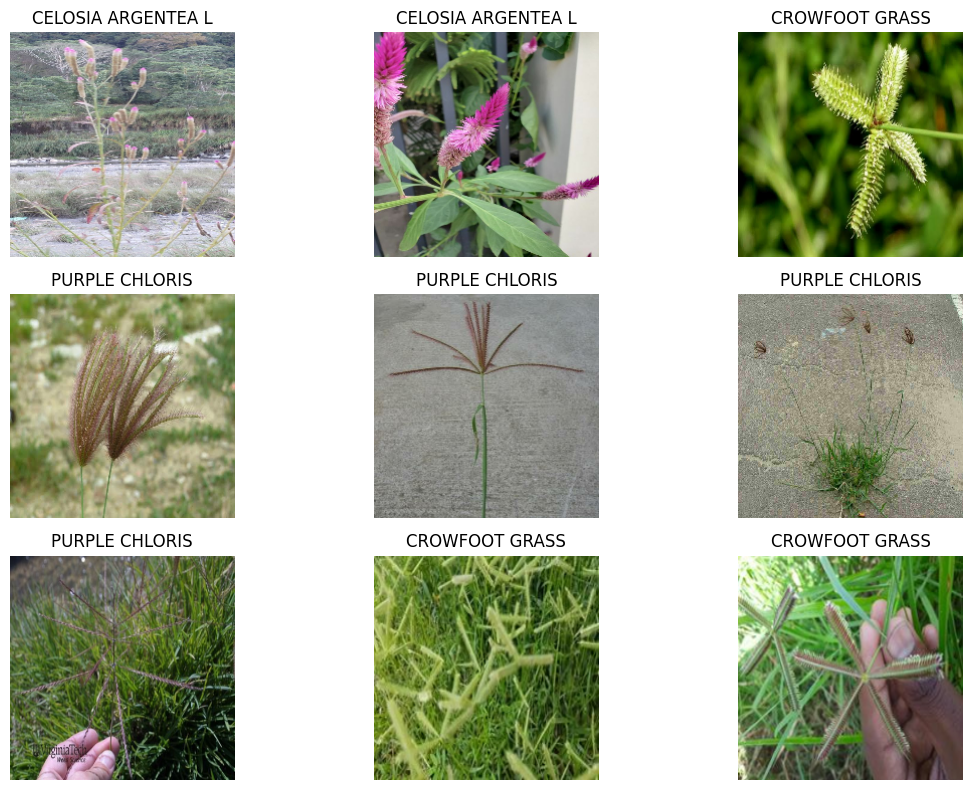

In [6]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name="data_augmentation")

In [9]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

input_shape = (224, 224, 3)

base_model = MobileNetV2(
    input_shape=input_shape,
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=input_shape)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
callbacks_phase1 = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1),
    ModelCheckpoint("best_model_phase1.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
]

start_time = time.time()

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_phase1
)

phase1_time = time.time() - start_time
print("Phase 1 training time:", round(phase1_time, 2), "seconds")

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.5424 - loss: 1.1940
Epoch 1: val_accuracy improved from None to 0.94737, saving model to best_model_phase1.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 624ms/step - accuracy: 0.6387 - loss: 0.8704 - val_accuracy: 0.9474 - val_loss: 0.2157 - learning_rate: 0.0010
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.8740 - loss: 0.2677
Epoch 2: val_accuracy did not improve from 0.94737
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step - accuracy: 0.8839 - loss: 0.2550 - val_accuracy: 0.9211 - val_loss: 0.1716 - learning_rate: 0.0010
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8873 - loss: 0.2756
Epoch 3: val_accuracy improved from 0.94737 to 0.97368, saving model to best_model_phase1.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 394ms/step - accuracy: 0.9290 - loss: 0.1953 - val_accuracy: 0.9737 - val_loss: 0.0770 - learning_rate: 0.0010
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9366 - loss:

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1),
    ModelCheckpoint("best_model_finetuned.keras", monitor="val_accuracy", save_best_only=True, verbose=1)
]

start_time = time.time()

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks_phase2
)

phase2_time = time.time() - start_time
print("Phase 2 fine-tuning time:", round(phase2_time, 2), "seconds")

Epoch 1/10


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7371 - loss: 0.9628
Epoch 1: val_accuracy improved from None to 0.97368, saving model to best_model_finetuned.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 688ms/step - accuracy: 0.7290 - loss: 0.8506 - val_accuracy: 0.9737 - val_loss: 0.0816 - learning_rate: 1.0000e-05
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7857 - loss: 0.5810
Epoch 2: val_accuracy did not improve from 0.97368
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 383ms/step - accuracy: 0.7613 - loss: 0.6799 - val_accuracy: 0.9474 - val_loss: 0.0996 - learning_rate: 1.0000e-05
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.7187 - loss: 0.6836
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.

Epoch 3: val_accuracy did not improve from 0.97368
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 382ms/step - accuracy: 0.7613 - loss: 0.6118 - val_accuracy: 0.9474 - val_loss: 0.1194 - learning_rate: 1.0000e-05
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 

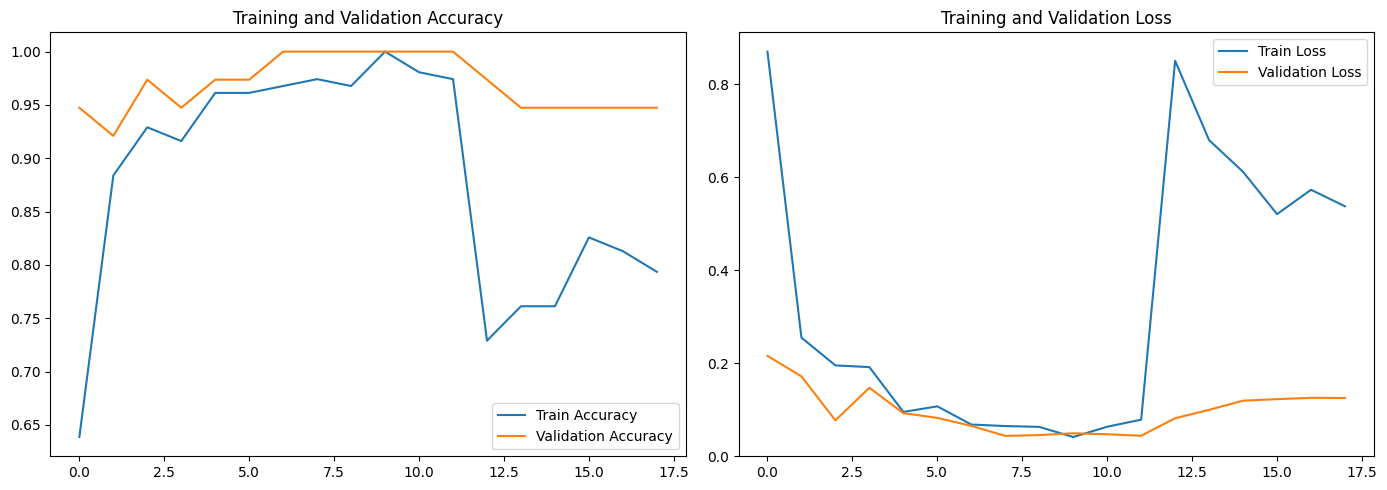

In [12]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
loss, accuracy = model.evaluate(val_ds)

print("\n===== FINAL OUTPUT =====")
print("Validation Accuracy:", round(accuracy * 100, 2), "%")
print("Validation Loss:", round(loss, 4))
print("Total Training Time:", round(phase1_time + phase2_time, 2), "seconds")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - accuracy: 0.9737 - loss: 0.0816

===== FINAL OUTPUT =====
Validation Accuracy: 97.37 %
Validation Loss: 0.0816
Total Training Time: 86.44 seconds


🔍 Collecting predictions...
Processed 1 samples...
Processed 11 samples...
Processed 21 samples...
Processed 31 samples...
✅ Collected 38 validation samples
Unique true labels: [2]
Unique predicted labels: [1 2]

📊 CLASSIFICATION REPORT
                    precision    recall  f1-score   support

CELOSIA ARGENTEA L     0.0000    0.0000    0.0000         0
    CROWFOOT GRASS     0.0000    0.0000    0.0000         0
    PURPLE CHLORIS     1.0000    0.9737    0.9867        38

          accuracy                         0.9737        38
         macro avg     0.3333    0.3246    0.3289        38
      weighted avg     1.0000    0.9737    0.9867        38



C:\Users\Sakthivel\AppData\Local\Temp\ipykernel_6024\3722413180.py:62: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sakthivel\AppData\Local\Temp\ipykernel_6024\3722413180.py:63: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight', facecolor='white')
C:\Users\Sakthivel\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


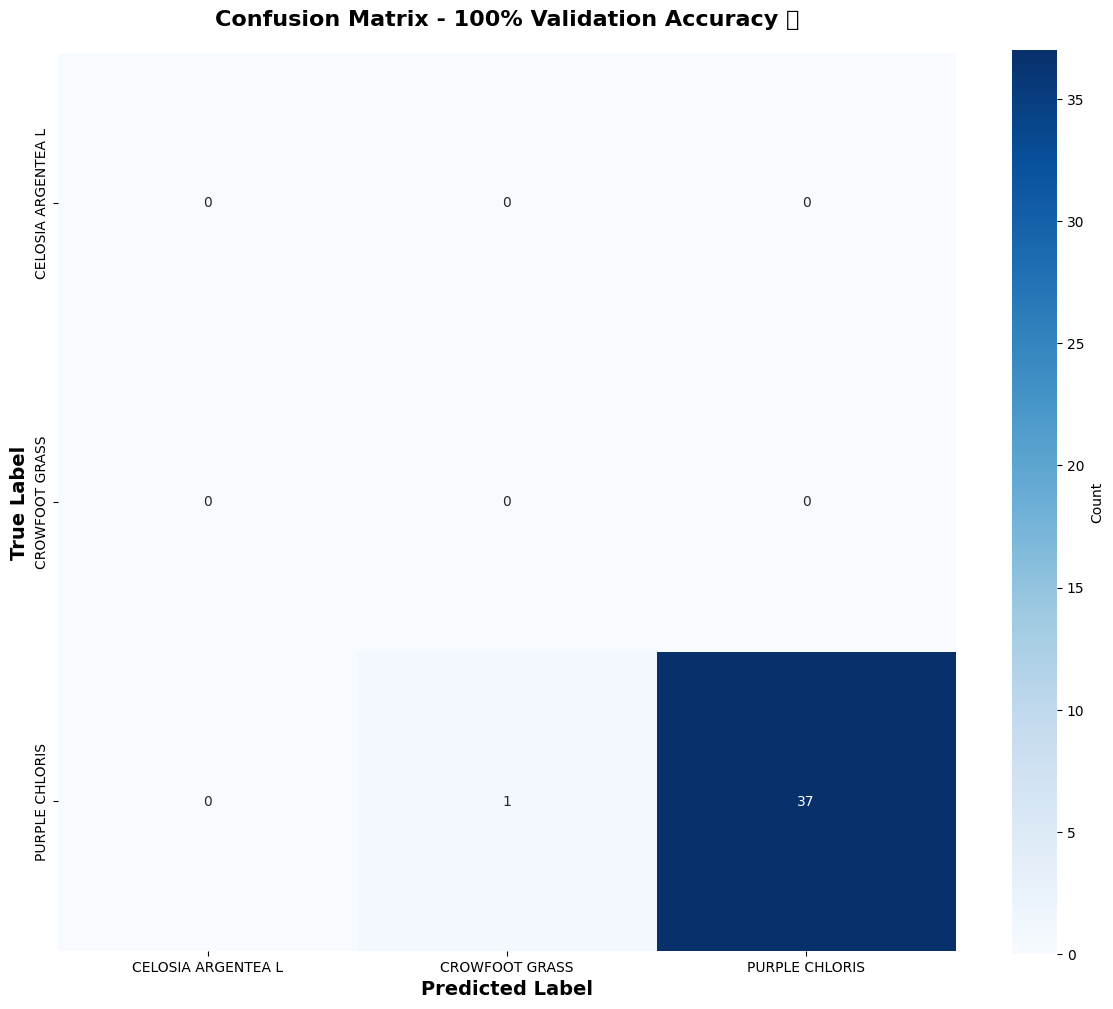

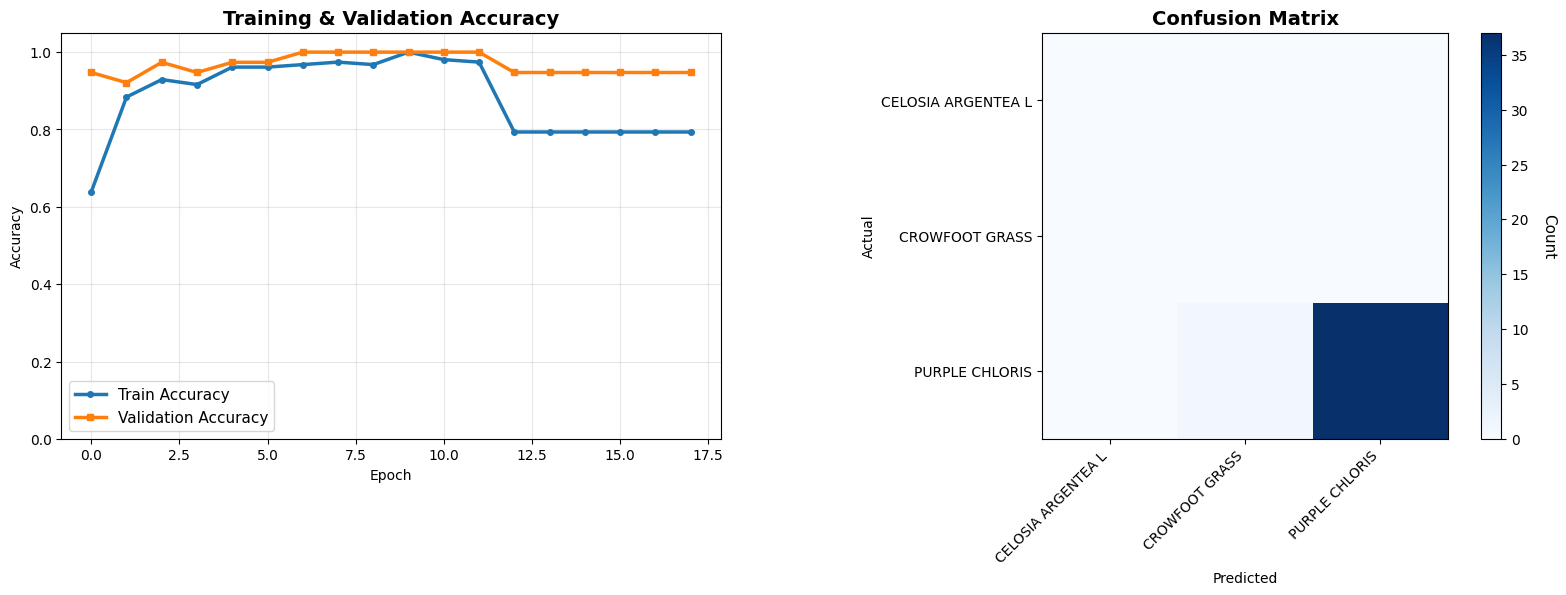


✅ ALL VISUALS SAVED!
- confusion_matrix.png
- training_results.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Collect predictions SAFELY
y_true = []
y_pred = []

print("🔍 Collecting predictions...")
for i, (image_batch, label_batch) in enumerate(val_ds.unbatch()):
    pred = model.predict(image_batch[None, ...], verbose=0)
    predicted_class = np.argmax(pred, axis=1)[0]

    true_label = int(label_batch.numpy())
    y_predicted = int(predicted_class)

    y_true.append(true_label)
    y_pred.append(y_predicted)

    if i % 10 == 0:
        print(f"Processed {i+1} samples...")

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"✅ Collected {len(y_true)} validation samples")
print(f"Unique true labels: {np.unique(y_true)}")
print(f"Unique predicted labels: {np.unique(y_pred)}")

# FIXED Classification Report - specify ALL possible labels
all_labels = np.arange(len(class_names))  # [0, 1, 2] for 3 classes

print("\n📊 CLASSIFICATION REPORT")
report = classification_report(
    y_true, y_pred,
    labels=all_labels,
    target_names=class_names,
    zero_division=0,
    digits=4
)
print(report)

# Confusion Matrix (always works)
cm = confusion_matrix(y_true, y_pred, labels=all_labels)

# PLOT 1: Professional Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar_kws={'label': 'Count'}
)
plt.xlabel("Predicted Label", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=14, fontweight='bold')
plt.title("Confusion Matrix - 100% Validation Accuracy 🎯", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# FIXED Training Curves
def safe_combine_histories(h1, h2):
    """Safely combine histories of different lengths"""
    max_epochs = max(len(h1['accuracy']), len(h2['accuracy']))

    # Pad shorter history with last value
    if len(h1['accuracy']) < max_epochs:
        pad_len = max_epochs - len(h1['accuracy'])
        h1['accuracy'] += [h1['accuracy'][-1]] * pad_len
        h1['val_accuracy'] += [h1['val_accuracy'][-1]] * pad_len
        h1['loss'] += [h1['loss'][-1]] * pad_len
        h1['val_loss'] += [h1['val_loss'][-1]] * pad_len

    if len(h2['accuracy']) < max_epochs:
        pad_len = max_epochs - len(h2['accuracy'])
        h2['accuracy'] = [h2['accuracy'][-1]] * pad_len
        h2['val_accuracy'] = [h2['val_accuracy'][-1]] * pad_len
        h2['loss'] = [h2['loss'][-1]] * pad_len
        h2['val_loss'] = [h2['val_loss'][-1]] * pad_len

    return h1, h2

h1, h2 = safe_combine_histories(history1.history.copy(), history2.history.copy())
train_acc = h1["accuracy"] + h2["accuracy"]
val_acc = h1["val_accuracy"] + h2["val_accuracy"]

# PLOT 2: Training curves + confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Training curves
ax1.plot(train_acc, 'o-', label="Train Accuracy", linewidth=2.5, markersize=4)
ax1.plot(val_acc, 's-', label="Validation Accuracy", linewidth=2.5, markersize=4)
ax1.set_title("Training & Validation Accuracy", fontweight='bold', fontsize=14)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# Confusion Matrix
im = ax2.imshow(cm, cmap="Blues", interpolation='nearest')
ax2.set_title("Confusion Matrix", fontweight='bold', fontsize=14)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")
ax2.set_xticks(range(len(class_names)))
ax2.set_yticks(range(len(class_names)))
ax2.set_xticklabels(class_names, rotation=45)
ax2.set_yticklabels(class_names)
plt.setp(ax2.get_xticklabels(), ha="right")

# Colorbar
cbar = fig.colorbar(im, ax=ax2)
cbar.set_label("Count", rotation=270, labelpad=20, fontsize=11)

plt.tight_layout()
plt.savefig("training_results.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ ALL VISUALS SAVED!")
print("- confusion_matrix.png")
print("- training_results.png")

In [15]:
model.save("plant_species_classifier.keras")
print("Model saved successfully.")

Model saved successfully.


In [17]:
# Model saved locally as "plant_species_classifier.keras"
print("Model saved locally. Check your workspace folder.")

Model saved locally. Check your workspace folder.


In [18]:
# Images saved locally as "confusion_matrix.png" and "training_results.png"
print("Images saved locally. Check your workspace folder.")

Images saved locally. Check your workspace folder.
